In [6]:
import pandas as pd
import os

sedes_olimpicas = {
    1960: "Itália", 1964: "Japão", 1968: "México", 1972: "Alemanha",
    1976: "Canadá", 1980: "União Soviética", 1984: "Estados Unidos", 1988: "Coreia do Sul",
    1992: "Espanha", 1996: "Estados Unidos", 2000: "Austrália", 2004: "Grécia",
    2008: "China", 2012: "Grã-Bretanha", 2016: "Brasil", 2020: "Japão", 2024: "França"
}

def buscar_medalhas_na_pasta(ano, pais_alvo):
    arquivos = [f for f in os.listdir('.') if f.endswith(f'_{ano}.csv')]
    if not arquivos: return None
    try:
        df = pd.read_csv(arquivos[0])
        res = df[df['País'].str.contains(pais_alvo, case=False, na=False)]
        return int(res.iloc[0]['Total']) if not res.empty else 0
    except: return None

analise_final = []
for ano, sede in sedes_olimpicas.items():
    analise_final.append({
        "Ano": ano,
        "Sede": sede,
        "Anterior": buscar_medalhas_na_pasta(ano - 4, sede),
        "Na Sede": buscar_medalhas_na_pasta(ano, sede),
        "Posterior": buscar_medalhas_na_pasta(ano + 4, sede)
    })

df_resultado = pd.DataFrame(analise_final)

colunas_med = ["Anterior", "Na Sede", "Posterior"]
for col in colunas_med:
    df_resultado[col] = df_resultado[col].fillna(0).astype(int)

print("--- ANÁLISE DO EFEITO CASA (OLIMPÍADAS) ---")
print(df_resultado.to_string(index=False)) 

df_resultado.to_csv("analise_efeito_casa_olimpico.csv", index=False)

--- ANÁLISE DO EFEITO CASA (OLIMPÍADAS) ---
 Ano            Sede  Anterior  Na Sede  Posterior
1960          Itália         0       36         27
1964           Japão        18       29         25
1968          México         1        9          1
1972        Alemanha        25       66         90
1976          Canadá         5       11          0
1980 União Soviética       125      195          0
1984  Estados Unidos         0      174         94
1988   Coreia do Sul        19       33         29
1992         Espanha         4       22         17
1996  Estados Unidos       108      101         93
2000       Austrália        41       58         50
2004          Grécia        13       16          3
2008           China        63      100         92
2012    Grã-Bretanha        51       65         67
2016          Brasil        17       19         21
2020           Japão        41       58         45
2024          França        33       64          0


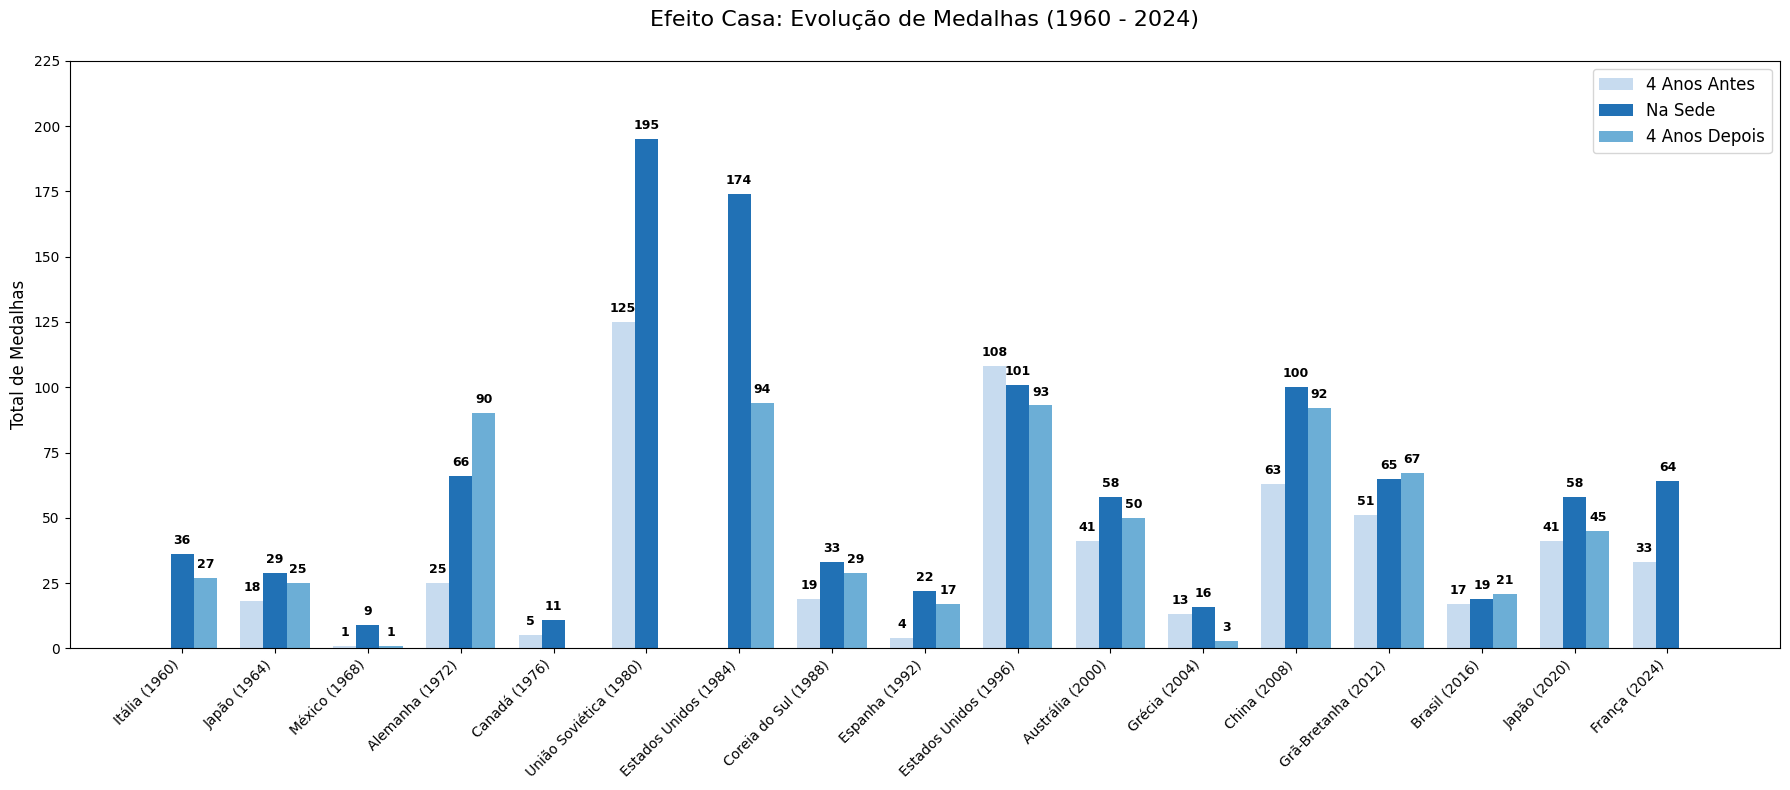

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 


df = pd.read_csv("analise_efeito_casa_olimpico.csv")
df = df.sort_values('Ano') 

df['Label'] = df['Sede'] + " (" + df['Ano'].astype(str) + ")"

x = np.arange(len(df))
width = 0.25 

fig, ax = plt.subplots(figsize=(18, 8))

paleta = sns.color_palette("Blues_r", 3)
cor_na_sede = paleta[0]    
cor_posterior = paleta[1]  
cor_anterior = paleta[2]   


rects1 = ax.bar(x - width, df['Anterior'], width, label='4 Anos Antes', color=cor_anterior)
rects2 = ax.bar(x, df['Na Sede'], width, label='Na Sede', color=cor_na_sede)
rects3 = ax.bar(x + width, df['Posterior'], width, label='4 Anos Depois', color=cor_posterior)

ax.set_ylabel('Total de Medalhas', fontsize=12)
ax.set_title('Efeito Casa: Evolução de Medalhas (1960 - 2024)', fontsize=16, pad=25)
ax.set_xticks(x)
ax.set_xticklabels(df['Label'], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate('{}'.format(int(height)),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_ylim(0, df['Na Sede'].max() + 30)

plt.tight_layout()
plt.savefig("grafico_efeito_casa_completo_blues.png", dpi=300)
plt.show()

o ano de 1980 e 1984. As barras "Anterior" ou "Posterior" estao zeradas por causa dos boicotes da Guerra Fria



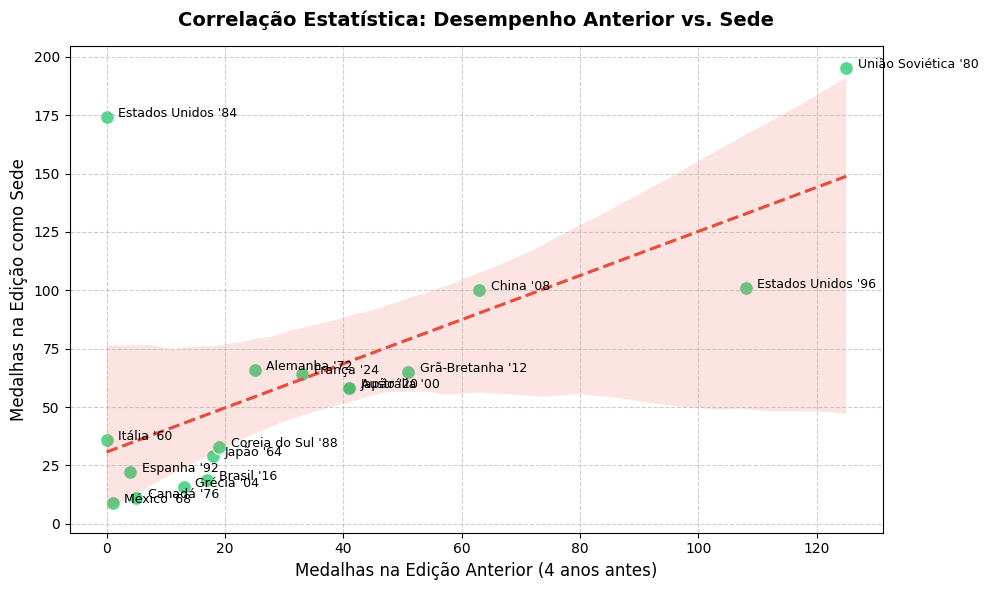

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("analise_efeito_casa_olimpico.csv")

# Remove apenas as linhas sem dados calculáveis (ex: 1960 não tem o ano de 1956 para comparar)
df_clean = df.dropna(subset=['Anterior', 'Na Sede']).copy()

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean, 
    x='Anterior', 
    y='Na Sede', 
    scatter_kws={'s': 100, 'color': '#2ecc71', 'edgecolor': 'white'}, 
    line_kws={'color': '#e74c3c', 'linestyle': '--'}
)

for i in range(df_clean.shape[0]):
    ano_abreviado = str(int(df_clean['Ano'].iloc[i]))[2:]
    plt.text(
        df_clean['Anterior'].iloc[i] + 2, 
        df_clean['Na Sede'].iloc[i], 
        f"{df_clean['Sede'].iloc[i]} '{ano_abreviado}", 
        fontsize=9
    )

plt.title('Correlação Estatística: Desempenho Anterior vs. Sede', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Medalhas na Edição Anterior (4 anos antes)', fontsize=12)
plt.ylabel('Medalhas na Edição como Sede', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('grafico_correlacao_linha_completo.png', dpi=300)
plt.show()

Se deixar os EUA de 84 ele puxa a linha pra cima


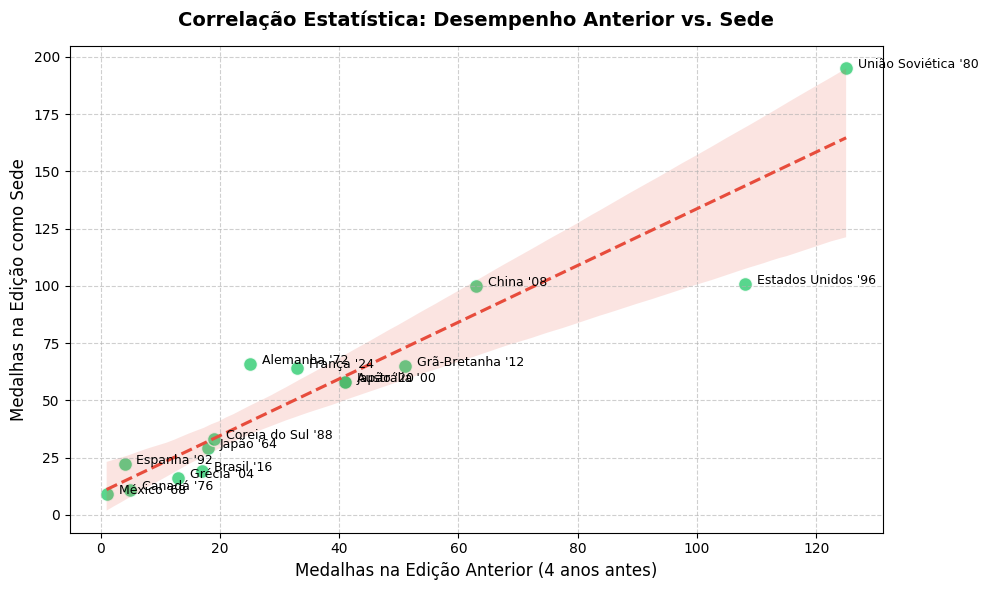

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("analise_efeito_casa_olimpico.csv")

# A mágica acontece aqui: 
# Removemos vazios E excluímos o boicote de 1984 (Anterior == 0) para não distorcer a linha
df_clean = df.dropna(subset=['Anterior', 'Na Sede'])
df_clean = df_clean[df_clean['Anterior'] > 0].copy()

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean, 
    x='Anterior', 
    y='Na Sede', 
    scatter_kws={'s': 100, 'color': '#2ecc71', 'edgecolor': 'white'}, 
    line_kws={'color': '#e74c3c', 'linestyle': '--'}
)

for i in range(df_clean.shape[0]):
    ano_abreviado = str(int(df_clean['Ano'].iloc[i]))[2:]
    plt.text(
        df_clean['Anterior'].iloc[i] + 2, 
        df_clean['Na Sede'].iloc[i], 
        f"{df_clean['Sede'].iloc[i]} '{ano_abreviado}", 
        fontsize=9
    )

plt.title('Correlação Estatística: Desempenho Anterior vs. Sede', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Medalhas na Edição Anterior (4 anos antes)', fontsize=12)
plt.ylabel('Medalhas na Edição como Sede', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('grafico_correlacao_linha.png', dpi=300)
plt.show()

sem eles a correlação fica mais certinha
